**Problem Statement:**

 Ninjacart is India's largest fresh produce supply chain company. They are pioneers in solving one of the toughest supply chain problems of the world by leveraging innovative technology. They source fresh produce from farmers and deliver them to businesses within 12 hours. An integral component of their automation process is the development of robust classifiers which can distinguish between images of different types of vegetables, while also correctly labeling images that do not contain any one type of vegetable as noise.

As a starting point, ninjacart has provided us with a dataset scraped from the web which contains train and test folders, each having 4 sub-folders with images of onions, potatoes, tomatoes and some market scenes. We have been tasked with preparing a multiclass classifier for identifying these vegetables. The dataset provided has all the required images to achieve the task.

**Our Approaches:**

*Multiclass Image Classification*:

Building a deep learning model that accurately classifies an input image into one of four categories: onion, potato, tomato, or market (noise), using convolutional neural networks and transfer learning techniques.

*Noise Detection Problem*:

Developing a classifier capable of distinguishing between vegetable images (onion, potato, tomato) and non-vegetable images (market scenes), ensuring robust handling of irrelevant inputs.

*Fine-Grained Classification Problem*:

Designing a model that can differentiate between visually similar vegetable classes such as onion and potato, minimizing inter-class misclassification.

*Overfitting & Generalization Problem*:

Investigateing techniques such as data augmentation, dropout, and transfer learning to reduce overfitting and improve model generalization on unseen test data.

*Transfer Learning Evaluation Problem*:

Comparing the performance of pretrained architectures (e.g., MobileNet, VGG, ResNet) against a custom CNN model to determine the most effective approach for small-scale image datasets.

*Data Imbalance & Distribution Problem*:

Analyzing class distribution and its impact on model performance, and apply techniques to mitigate bias toward majority classes.

*Model Explainability Problem*:

Evaluating model predictions using visualization techniques (e.g., Grad-CAM) to understand which features influence classification decisions.

*Multi-Objective Optimization Problem*:

Optimizing the trade-off between model accuracy, inference speed, and computational cost for practical deployment in supply chain automation.

*Error Analysis Problem*:

Performing detailed error analysis using confusion matrices to identify patterns of misclassification and improve model robustness.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import glob
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
file_path = '/content/ninjacart_data.zip'

if os.path.exists(file_path):
    stats = os.stat(file_path)
    print(f"File size: {stats.st_size / (1024 * 1024):.2f} MB")
else:
    print("File not found! Check the file name and path.")

File size: 31.00 MB


In [6]:
!unzip -q /content/ninjacart_data.zip -d /content

In [7]:
dataset_dir = "ninjacart_data"
print("Contents of the dataset directory:")
print(os.listdir(dataset_dir))

Contents of the dataset directory:
['train', 'test']


# Exploratory Data Analysis (EDA)

We will perform exploratory data analysis by identifying class labels, counting images, and visualizing samples to understand dataset structure before training the model.

In [8]:
class DatasetAnalyzer:
    """
    Reusable dataset analysis pipeline:
    - Class extraction
    - Image counting
    - Sampling images
    """

    def __init__(self, dataset_dir):
        self.dataset_dir = dataset_dir

    def get_class_names(self, split):
        split_path = os.path.join(self.dataset_dir, split)

        return sorted([
            d for d in os.listdir(split_path)
            if os.path.isdir(os.path.join(split_path, d))
        ])

    def get_image_counts(self, split, class_names):
        split_path = os.path.join(self.dataset_dir, split)
        counts = {}

        for cls in class_names:
            class_path = os.path.join(split_path, cls)
            counts[cls] = len(glob.glob(os.path.join(class_path, "*")))

        return counts

    def sample_images(self, split, class_names):
        split_path = os.path.join(self.dataset_dir, split)
        samples = {}

        for cls in class_names:
            class_path = os.path.join(split_path, cls)
            images = glob.glob(os.path.join(class_path, "*"))

            if images:
                samples[cls] = tf.keras.utils.load_img(random.choice(images))

        return samples

In [9]:
class DatasetVisualizer:

    @staticmethod
    def plot_samples(sample_dict, cols=2):
        plt.figure(figsize=(12, 8))

        for i, (cls, img) in enumerate(sample_dict.items()):
            plt.subplot((len(sample_dict)+cols-1)//cols, cols, i+1)
            plt.imshow(img)
            plt.title(f"{cls} | {img.size}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_distribution(train_counts, test_counts):
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))

        ax[0].bar(train_counts.keys(), train_counts.values(), color='skyblue')
        ax[0].set_title("Train Distribution")
        ax[0].tick_params(axis='x', rotation=45)

        ax[1].bar(test_counts.keys(), test_counts.values(), color='lightgreen')
        ax[1].set_title("Test Distribution")
        ax[1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

Train classes: ['indian market', 'onion', 'potato', 'tomato']
Train counts: {'indian market': 599, 'onion': 849, 'potato': 898, 'tomato': 789}
Test counts: {'indian market': 81, 'onion': 83, 'potato': 81, 'tomato': 106}


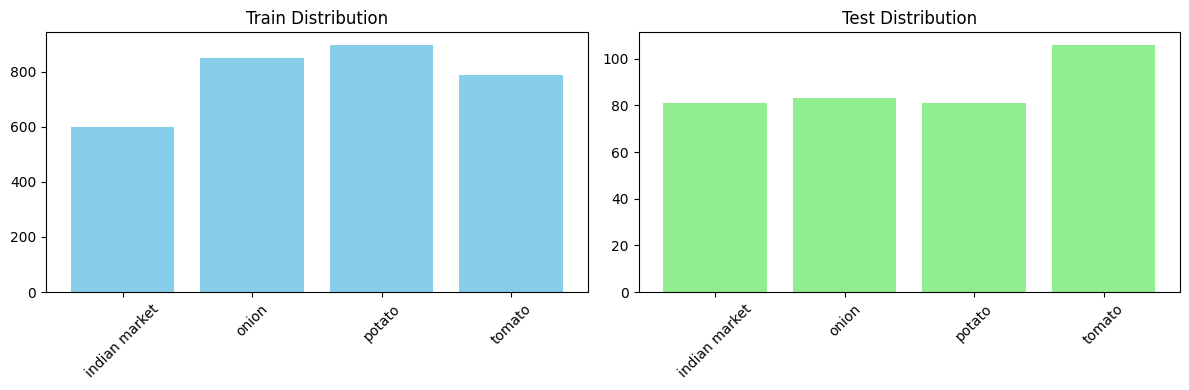

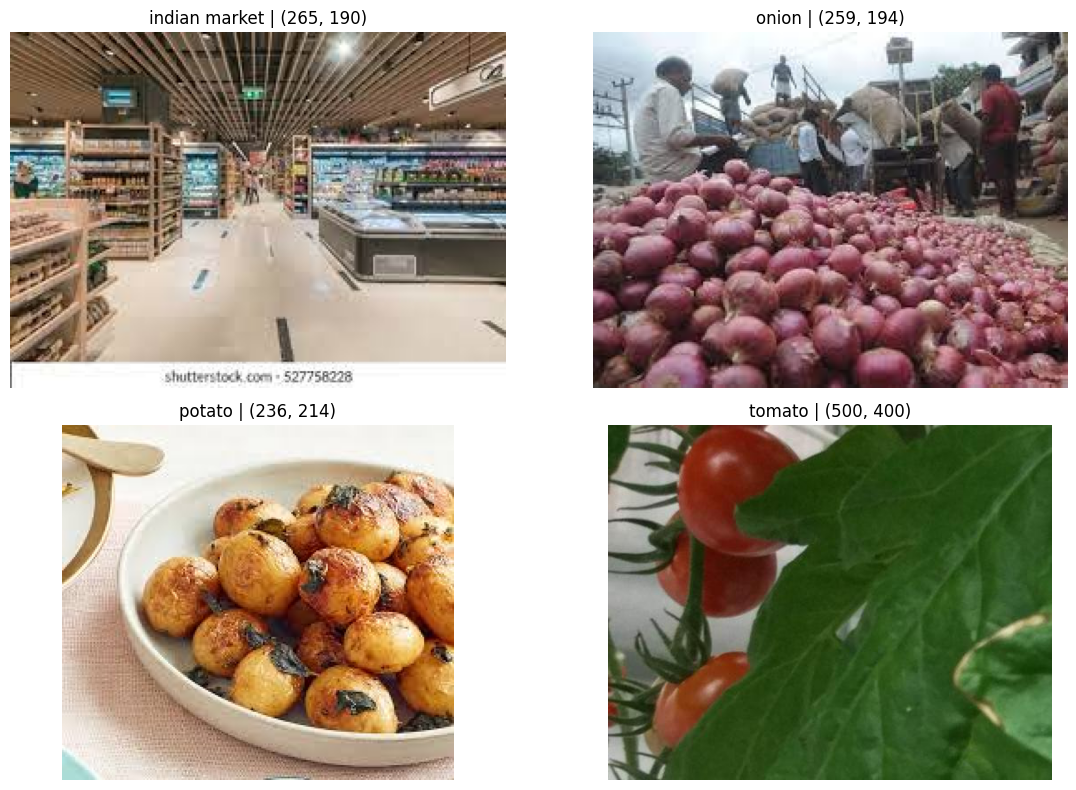

In [10]:
DATASET_DIR = "ninjacart_data"

analyzer = DatasetAnalyzer(DATASET_DIR)
visualizer = DatasetVisualizer()

# -------------------------------
# TRAIN ANALYSIS
# -------------------------------
train_classes = analyzer.get_class_names("train")
train_counts = analyzer.get_image_counts("train", train_classes)
train_samples = analyzer.sample_images("train", train_classes)

print("Train classes:", train_classes)
print("Train counts:", train_counts)

# -------------------------------
# TEST ANALYSIS
# -------------------------------
test_counts = analyzer.get_image_counts("test", train_classes)

print("Test counts:", test_counts)

# -------------------------------
# VISUALIZATION
# -------------------------------
visualizer.plot_distribution(train_counts, test_counts)
visualizer.plot_samples(train_samples)

In [11]:
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = "ninjacart_data/test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [12]:
class DataPipeline:

    def __init__(self, dataset_dir, img_size=(128,128), batch_size=32):
        self.dataset_dir = dataset_dir
        self.img_size = img_size
        self.batch_size = batch_size

    def create_generators(self):

        datagen = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.2
        )

        train_gen = datagen.flow_from_directory(
            os.path.join(self.dataset_dir, "train"),
            target_size=self.img_size,
            batch_size=self.batch_size,
            class_mode='categorical',
            subset='training',
            shuffle=True
        )

        val_gen = datagen.flow_from_directory(
            os.path.join(self.dataset_dir, "train"),
            target_size=self.img_size,
            batch_size=self.batch_size,
            class_mode='categorical',
            subset='validation',
            shuffle=False
        )

        test_datagen = ImageDataGenerator(rescale=1./255)

        test_gen = test_datagen.flow_from_directory(
            os.path.join(self.dataset_dir, "test"),
            target_size=self.img_size,
            batch_size=self.batch_size,
            class_mode='categorical',
            shuffle=False
        )

        self.class_names = list(train_gen.class_indices.keys())

        return train_gen, val_gen, test_gen, self.class_names

In [13]:
class CNNModel:

    def __init__(self, input_shape=(128,128,3), num_classes=4):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def build_model(self):

        model = tf.keras.Sequential([

            layers.Input(shape=self.input_shape),

            layers.Conv2D(32, 3, activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Dropout(0.25),

            layers.Conv2D(64, 3, activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Dropout(0.25),

            layers.Conv2D(128, 3, activation='relu', padding='same'),

            layers.GlobalAveragePooling2D(),

            layers.Dense(128, activation='relu'),
            layers.Dropout(0.4),

            layers.Dense(self.num_classes, activation='softmax')
        ])

        return model

    def compile_model(self, model):

        model.compile(
            optimizer=tf.keras.optimizers.Adam(0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        return model

In [14]:
class ModelFactory:

    def __init__(self, num_classes):
        self.num_classes = num_classes

    # ---------------- CNN ----------------
    def build_cnn(self):

        model = tf.keras.Sequential([
            layers.Input(shape=(128,128,3)),

            layers.Conv2D(32,3,activation='relu',padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Dropout(0.2),

            layers.Conv2D(64,3,activation='relu',padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Dropout(0.3),

            layers.Conv2D(128,3,activation='relu',padding='same'),

            layers.GlobalAveragePooling2D(),

            layers.Dense(128, activation='relu'),
            layers.Dropout(0.4),

            layers.Dense(self.num_classes, activation='softmax')
        ])

        return model

    # ---------------- VGG16 ----------------
    def build_vgg16(self):

        base = tf.keras.applications.VGG16(
            weights='imagenet',
            include_top=False,
            input_shape=(128,128,3)
        )
        base.trainable = False

        model = tf.keras.Sequential([
            base,
            layers.GlobalAveragePooling2D(),
            layers.Dense(self.num_classes, activation='softmax')
        ])

        return model

    # ---------------- VGG19 ----------------
    def build_vgg19(self):

        base = tf.keras.applications.VGG19(
            weights='imagenet',
            include_top=False,
            input_shape=(128,128,3)
        )
        base.trainable = False

        model = tf.keras.Sequential([
            base,
            layers.GlobalAveragePooling2D(),
            layers.Dense(self.num_classes, activation='softmax')
        ])

        return model

    # ---------------- RESNET101 ----------------
    def build_resnet(self):

        base = tf.keras.applications.ResNet101(
            weights='imagenet',
            include_top=False,
            input_shape=(128,128,3)
        )
        base.trainable = False

        model = tf.keras.Sequential([
            base,
            layers.GlobalAveragePooling2D(),
            layers.Dense(self.num_classes, activation='softmax')
        ])

        return model

In [16]:
data_pipeline = DataPipeline(DATASET_DIR)
train_gen, val_gen, test_gen, class_names = data_pipeline.create_generators()

print("Class mapping:", train_gen.class_indices)
print("Train batches:", len(train_gen))
print("Test batches:", len(test_gen))
print("Validation batches:", len(val_gen))

Found 2511 images belonging to 4 classes.
Found 624 images belonging to 4 classes.
Found 351 images belonging to 4 classes.
Class mapping: {'indian market': 0, 'onion': 1, 'potato': 2, 'tomato': 3}
Train batches: 79
Test batches: 11
Validation batches: 20


In [22]:
class ModelEvaluator:

    def __init__(self, model, class_names):
        self.model = model
        self.class_names = class_names

    def full_evaluation(self, history, test_gen):
      self.plot_accuracy(history)
      self.plot_loss(history)
      self.evaluate(test_gen)
      self.confusion_matrix(test_gen)

    def plot_accuracy(self, history):

        plt.plot(history.history['accuracy'], label='Train')
        plt.plot(history.history['val_accuracy'], label='Val')

        plt.title("Accuracy Curve")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

    def plot_loss(self, history):

        plt.plot(history.history['loss'], label='Train')
        plt.plot(history.history['val_loss'], label='Val')

        plt.title("Loss Curve")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

    def confusion_matrix(self, test_gen):

        y_true = []
        y_pred = []

        for images, labels in test_gen:
            preds = self.model.predict(images, verbose=0)

            y_true.extend(np.argmax(labels, axis=1))
            y_pred.extend(np.argmax(preds, axis=1))

            if len(y_true) >= test_gen.samples:
                break

        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(6,5))
        sns.heatmap(cm,
                    annot=True,
                    fmt='d',
                    xticklabels=self.class_names,
                    yticklabels=self.class_names,
                    cmap='Blues')

        plt.title("Confusion Matrix")
        plt.show()

    def evaluate(self, test_gen):

        loss, acc = self.model.evaluate(test_gen)
        print(f"\nTest Accuracy: {acc*100:.2f}%")

        self.confusion_matrix(test_gen)

    def visualize_predictions(self, test_gen, num_samples=4):
      class_names = self.class_names

      for i in range(num_samples):

          images, labels = next(test_gen)

          idx = np.random.randint(0, images.shape[0])
          img = images[idx]

          pred = self.model.predict(np.expand_dims(img, axis=0), verbose=0)
          pred_class = np.argmax(pred)

          plt.subplot(1, num_samples, i+1)
          plt.imshow(img)

          plt.title(f"Pred: {class_names[pred_class]}")
          plt.axis("off")

          plt.show()

In [23]:
class Trainer:

    def compile(self, model):

        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        return model

    def get_callbacks(self):

        return [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True
            )
        ]

    def train(self, model, train_gen, val_gen, epochs=15):

        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=epochs,
            callbacks=self.get_callbacks()
        )

        return history

# Pipeline Execution

In [24]:
def run_model(name, model, trainer, evaluator,
              train_gen, val_gen, test_gen, class_names, epochs=15):

    print("\n==============================")
    print("Training:", name)
    print("==============================")

    model = trainer.compile(model)

    history = trainer.train(model, train_gen, val_gen, epochs)

    evaluator.model = model

    evaluator.full_evaluation(history, test_gen)

    return model, history

In [25]:
# ---------------- DATA ----------------
data = DataPipeline("ninjacart_data")
train_gen, val_gen, test_gen, class_names = data.create_generators()

# ---------------- SYSTEM ----------------
factory = ModelFactory(num_classes=len(class_names))
trainer = Trainer()

Found 2511 images belonging to 4 classes.
Found 624 images belonging to 4 classes.
Found 351 images belonging to 4 classes.


# CNN


Training: CNN
Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 280ms/step - accuracy: 0.7196 - loss: 0.6815 - val_accuracy: 0.4599 - val_loss: 1.3018
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step - accuracy: 0.8037 - loss: 0.5193 - val_accuracy: 0.5064 - val_loss: 1.4592
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.8104 - loss: 0.4921 - val_accuracy: 0.5032 - val_loss: 1.5159
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.8284 - loss: 0.4371 - val_accuracy: 0.5449 - val_loss: 1.2591
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.8240 - loss: 0.4425 - val_accuracy: 0.5208 - val_loss: 1.6526
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.8463 - loss: 0.3996 - val_accuracy: 0.4888 - val_loss: 1.8468
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.8523 - loss: 0.3942 - val_accuracy: 0.6843 - val_loss: 0.8463
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.8586 - loss: 0.

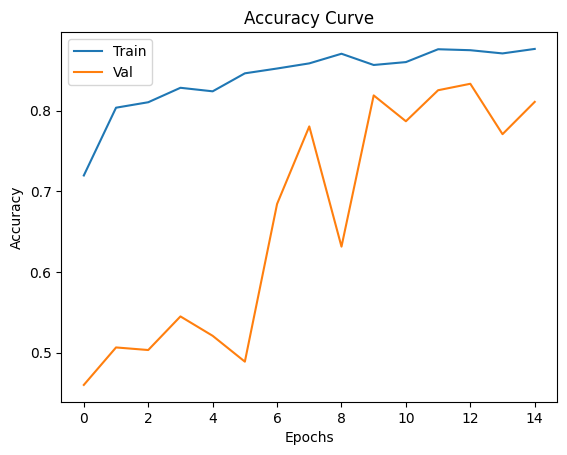

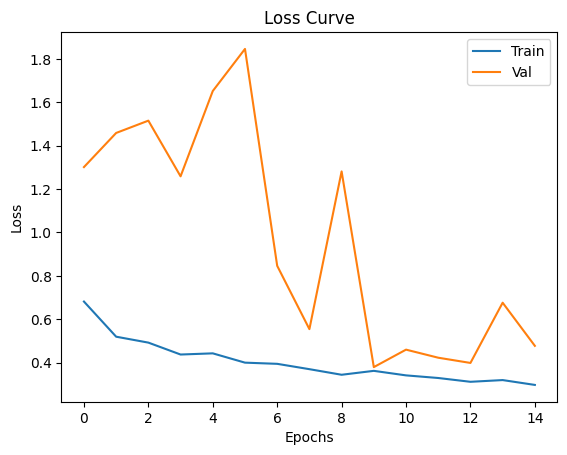

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.7806 - loss: 0.5411

Test Accuracy: 78.06%


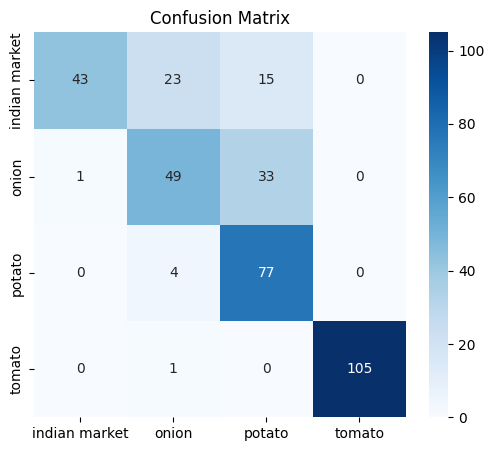

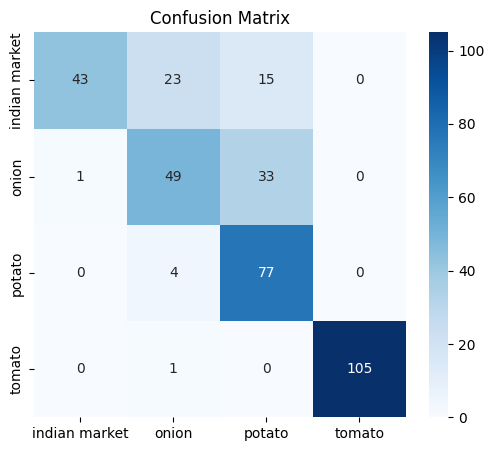

In [26]:
DATASET_DIR = "ninjacart_data"
cnn = factory.build_cnn()
cnn_eval = ModelEvaluator(cnn, class_names)

cnn, cnn_hist = run_model(
    "CNN",
    cnn,
    trainer,
    cnn_eval,
    train_gen,
    val_gen,
    test_gen,
    class_names,
    epochs=15
)

# VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

Training: VGG16
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 320ms/step - accuracy: 0.6388 - loss: 1.0254 - val_accuracy: 0.7500 - val_loss: 0.7891
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 182ms/step - accuracy: 0.7861 - loss: 0.7050 - val_accuracy: 0.8029 - val_loss: 0.6213
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.8152 - loss: 0.5816 - val_accuracy: 0.8462 - val_loss: 0.5318
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 156ms/step - accuracy: 0.8331 - loss: 0.5127 - val_accuracy: 0.8558 - val_loss: 0.4826
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.8479 - loss: 0.4678 - val_accuracy: 0.8702 - val_loss: 0.4453
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.8538 - loss: 0.4356 - val_accuracy: 0.8750 - val_loss: 0.4196
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.8610 - loss: 0.4109 - val_accuracy: 0.8750 - val_loss: 0.4005
Epoch 8/10
79/79 ━━━━━━━━━━━━

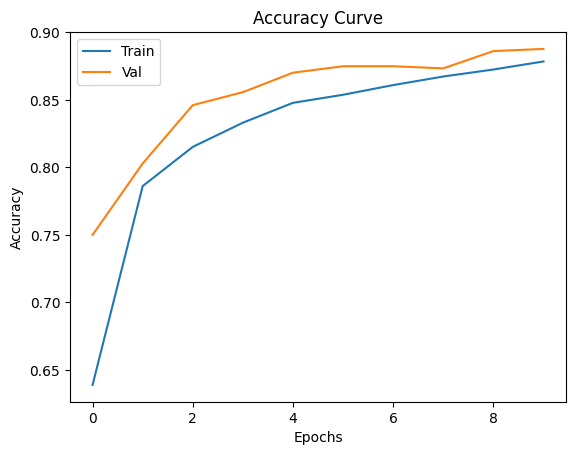

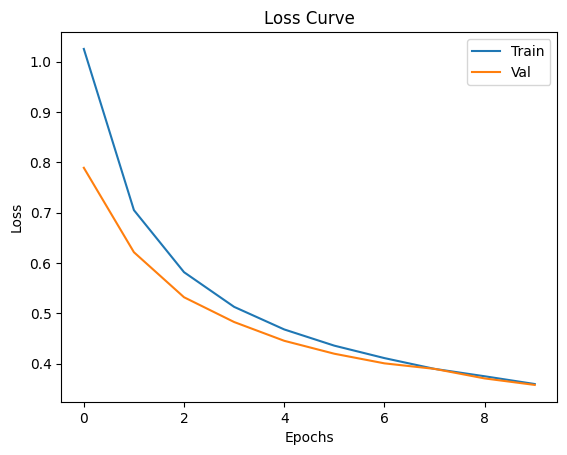

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 810ms/step - accuracy: 0.7949 - loss: 0.5498

Test Accuracy: 79.49%


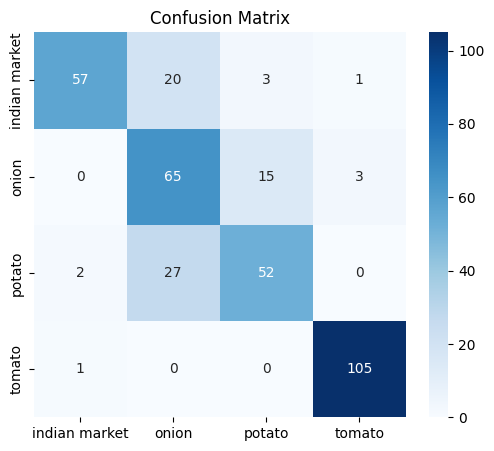

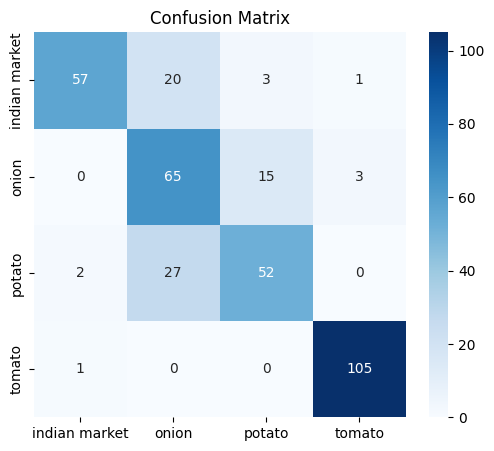

In [27]:
vgg16 = factory.build_vgg16()
vgg16_eval = ModelEvaluator(vgg16, class_names)

vgg16, vgg16_hist = run_model(
    "VGG16",
    vgg16,
    trainer,
    vgg16_eval,
    train_gen,
    val_gen,
    test_gen,
    class_names,
    epochs=10
)


# VGG19

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

Training: VGG19
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 234ms/step - accuracy: 0.5663 - loss: 1.1655 - val_accuracy: 0.7196 - val_loss: 0.9021
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 166ms/step - accuracy: 0.7654 - loss: 0.7899 - val_accuracy: 0.7756 - val_loss: 0.7014
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 166ms/step - accuracy: 0.7977 - loss: 0.6494 - val_accuracy: 0.7901 - val_loss: 0.6108
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.8108 - loss: 0.5736 - val_accuracy: 0.8077 - val_loss: 0.5551
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.8236 - loss: 0.5230 - val_accuracy: 0.8125 - val_loss: 0.5228
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - accuracy: 0.8315 - loss: 0.4878 - val_accuracy: 0.8349 - val_loss: 0.4904
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.8447 - loss: 0.4595 - val_accuracy: 0.8093 - val_loss: 0.4739
Epoch 8/10
79/79 ━━━━━━━━━━━━

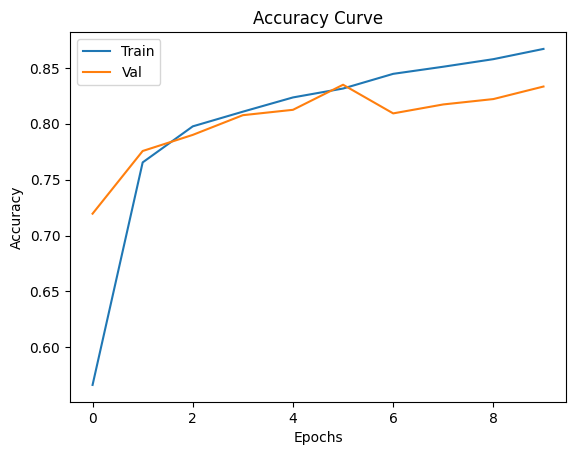

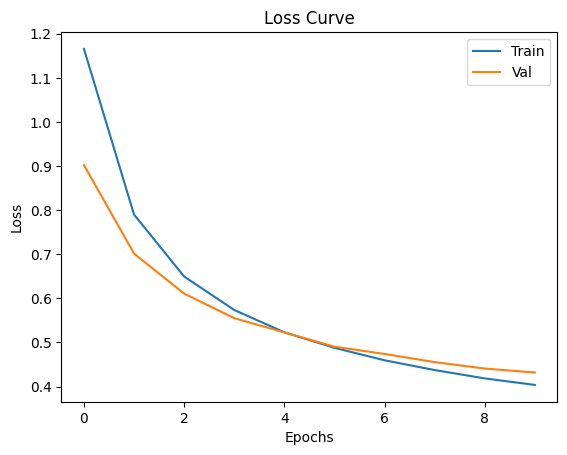

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.8063 - loss: 0.5627

Test Accuracy: 80.63%


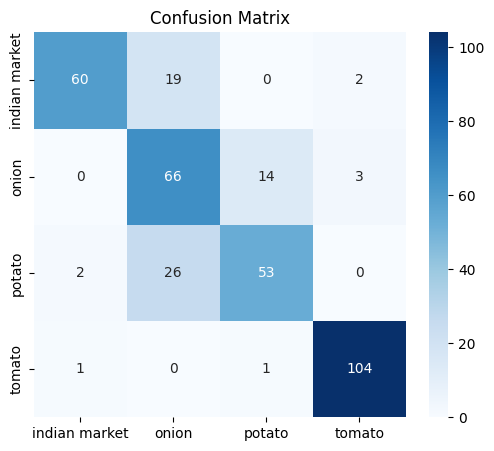

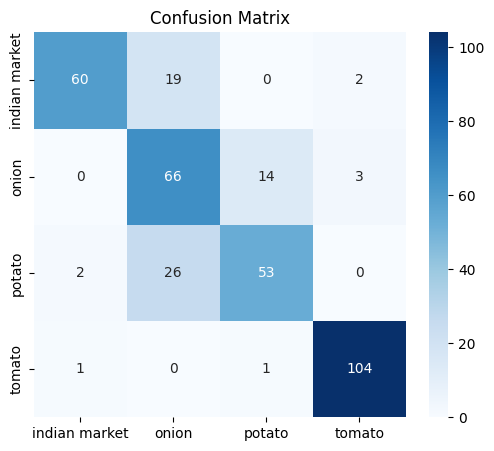

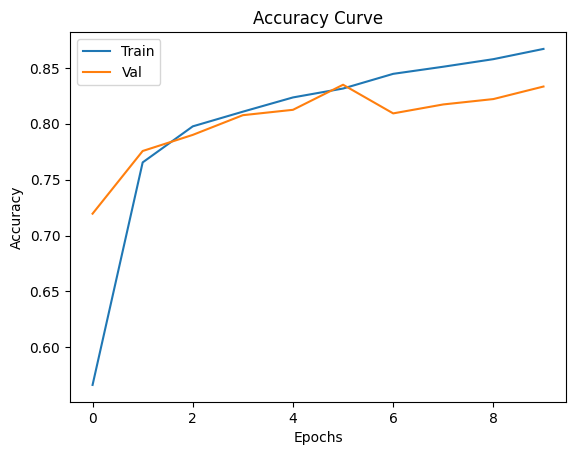

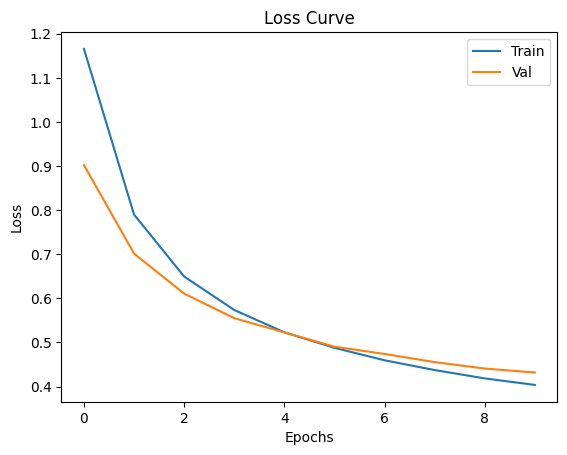

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.8063 - loss: 0.5627

Test Accuracy: 80.63%


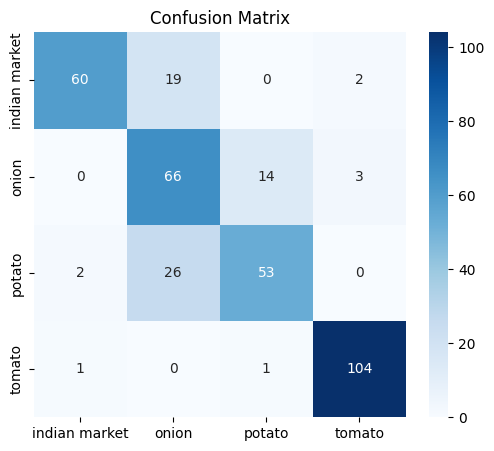

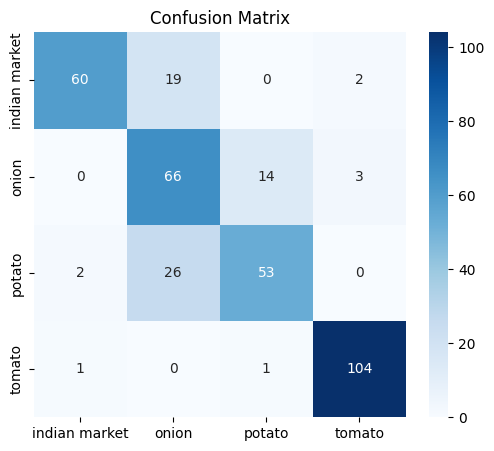

In [28]:
vgg19 = factory.build_vgg19()
vgg19_eval = ModelEvaluator(vgg19, class_names)

vgg19, vgg19_hist = run_model(
    "VGG19",
    vgg19,
    trainer,
    vgg19_eval,
    train_gen,
    val_gen,
    test_gen,
    class_names,
    epochs=10
)

vgg19_eval.full_evaluation(vgg19_hist, test_gen)

# RESNET101


Training: ResNet101
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 359ms/step - accuracy: 0.2995 - loss: 1.3654 - val_accuracy: 0.3301 - val_loss: 1.3370
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - accuracy: 0.3616 - loss: 1.3193 - val_accuracy: 0.3638 - val_loss: 1.3047
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.3879 - loss: 1.2898 - val_accuracy: 0.4263 - val_loss: 1.2802
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.4341 - loss: 1.2647 - val_accuracy: 0.4311 - val_loss: 1.2573
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 166ms/step - accuracy: 0.4524 - loss: 1.2451 - val_accuracy: 0.4279 - val_loss: 1.2483
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step - accuracy: 0.4568 - loss: 1.2298 - val_accuracy: 0.4455 - val_loss: 1.2274
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 166ms/step - accuracy: 0.4715 - loss: 1.2163 - val_accuracy: 0.4503 - val_loss: 1.2171
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 167ms/step - accuracy: 0.4839 - lo

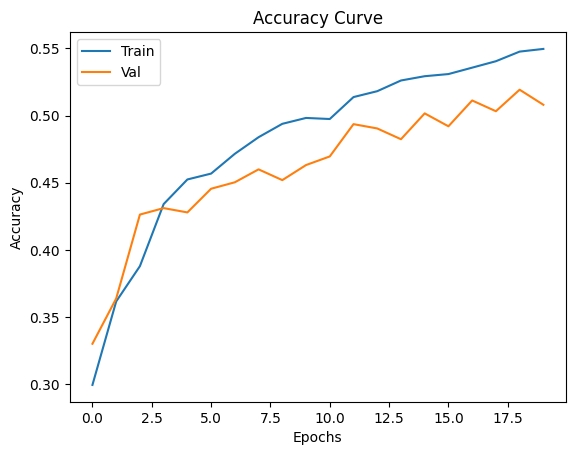

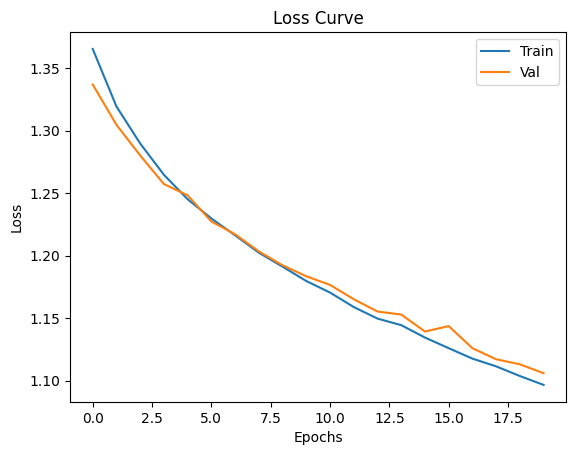

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 484ms/step - accuracy: 0.3875 - loss: 1.2086

Test Accuracy: 38.75%


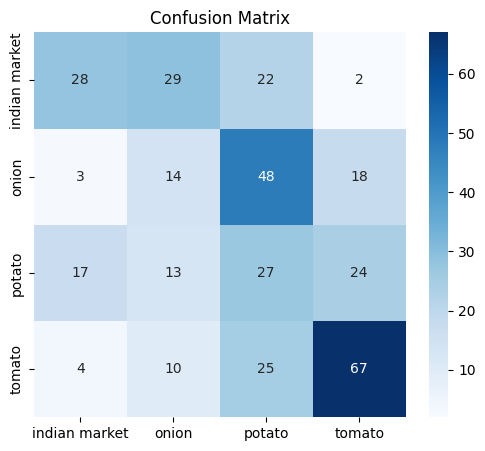

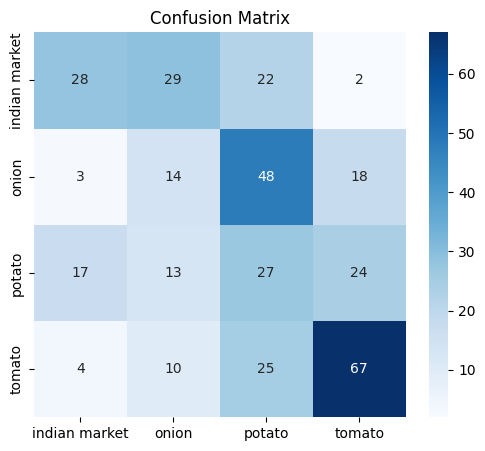

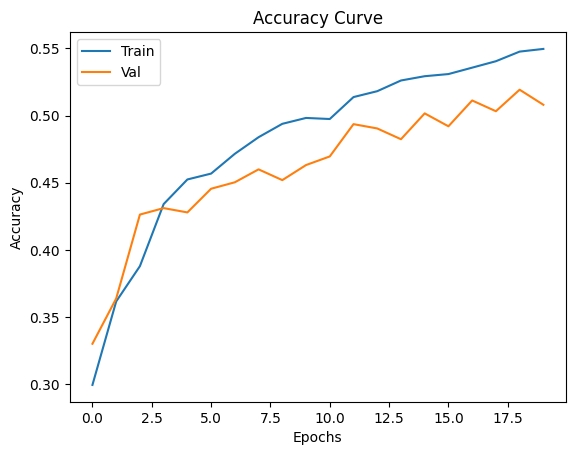

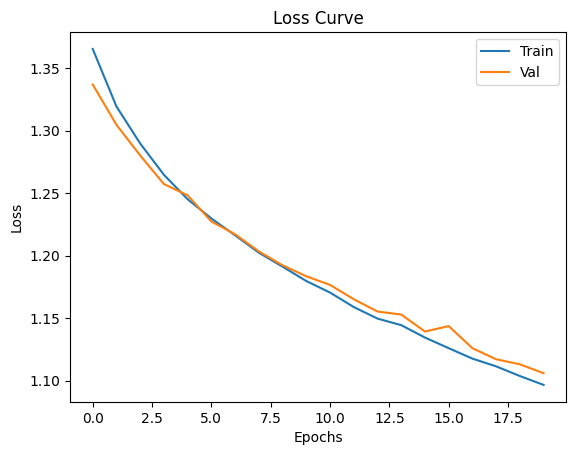

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - accuracy: 0.3875 - loss: 1.2086

Test Accuracy: 38.75%


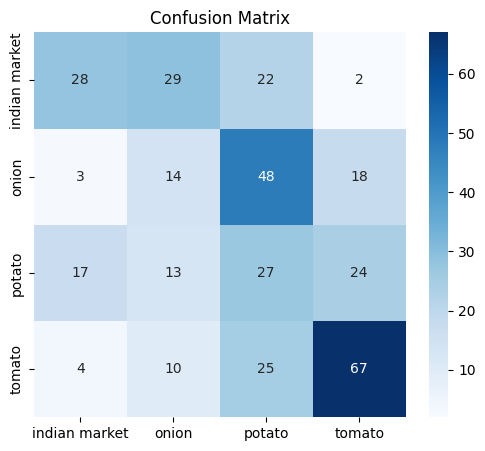

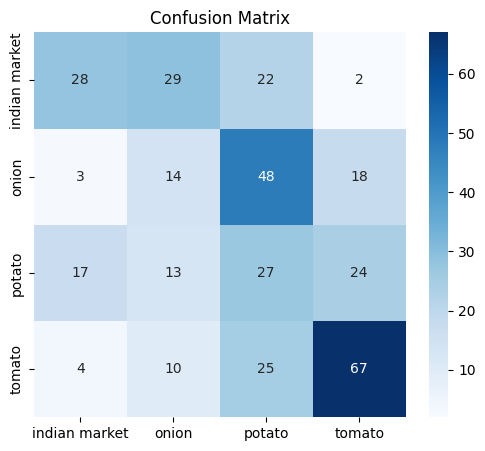

In [31]:
resnet = factory.build_resnet()
resnet_eval = ModelEvaluator(resnet, class_names)

resnet, resnet_hist = run_model(
    "ResNet101",
    resnet,
    trainer,
    resnet_eval,
    train_gen,
    val_gen,
    test_gen,
    class_names,
    epochs=20
)

resnet_eval.full_evaluation(resnet_hist, test_gen)

As we can see, the VGG19 and VGG16 architectures provided the most stable and highest accuracy on the test dataset.VGG19: Achieved a Test Accuracy of 80.63%. It showed strong generalization with a validation accuracy of approximately 83.33% by the 10th epoch.VGG16: Achieved a Test Accuracy of 79.49%.

It reached a **validation** **accuracy of 88.78%** quickly, making it a very strong contender.Custom CNN: While it achieved high training accuracy (87.65%), its performance was more volatile, and it required more epochs to stabilize compared to the transfer learning models.

**ResNet101:** Performed poorly on this specific dataset, only reaching about 54.76% accuracy after 20 epochs. This suggests that for a small-scale dataset (2,500 training images), heavier architectures like ResNet101 may lead to vanishing gradients or require more extensive tuning

The document outlines several critical problems that these models solve for a high-speed supply chain like Ninjacart:

**12-Hour Delivery Constraint:** Ninjacart delivers produce from farmers to businesses within 12 hours. AI models automate the sorting process, which is an "integral component" of meeting this tight deadline by replacing slow manual classification.

**Noise Filtering:** The "Indian Market" class acts as a filter. This ensures that "noise" (images not containing specific vegetables) is correctly labeled, preventing irrelevant data from entering the supply chain automation system.

**Handling Visual Similarity:** A major challenge identified is "Fine-Grained Classification"—distinguishing between visually similar items like onions and potatoes. The success of VGG19 (80.63% accuracy) indicates that transfer learning is effective at picking up these subtle textural differences.

For your institutional presentation, you can frame this project not just as a "coding exercise," but as a Digital Transformation Case Study. Transitioning from manual sorting to AI-driven classification solves the "Three Pillars of Logistics": Speed, Accuracy, and Scale.

Here are the key insights and talking points to help you promote the use of AI in this context:

**1. The Limitations of Manual Processes**
In a traditional supply chain (like a local Mandi), quality checks are done by human eyes. This presents three major business risks:

Subjectivity & Fatigue: Human graders get tired after 8 hours. What one worker considers a "Grade A" tomato might be "Grade B" to another, especially toward the end of a shift.

Latency (The 12-Hour Clock): Ninjacart operates on a 12-hour farm-to-store cycle. Manual sorting is a massive bottleneck. If it takes 2 hours to sort a truckload manually, the produce is already losing freshness.

Lack of Traceability: Manual sorting leaves no "data trail." If a batch of onions is bad, there is no photographic evidence of where the quality control failed.

**2. AI as an Efficiency Multiplier**
By implementing a Convolutional Neural Network (CNN) like the one you are building, the business shifts from reactive to proactive operations:

Standardization of Quality: The AI applies the exact same mathematical weights to every image. It doesn't get tired, and it doesn't have a "bad day." This ensures consistent quality across different warehouses.

High-Velocity Throughput: An optimized AI model (like MobileNet) can classify an image in milliseconds. This allows for automated conveyor belt systems where produce is sorted in real-time.

Cost Efficiency (OPEX reduction): While there is an initial cost to develop the AI, the operational cost per ton of sorted produce drops significantly over time compared to hiring and training hundreds of manual sorters.

The shift from Manual to AI isn't just about replacing eyes; it’s about converting visual information into actionable data at a speed that humans cannot match, ensuring the 'Freshness Promise' of the 12-hour supply chain.